# Predicción del fútbol uruguayo: ID3 propio y Naive Bayes

En este notebook entrenamos dos clasificadores implementados a mano para
predecir si un partido de primera división lo gana el local (L), termina en
empate (E) o lo gana el visitante (V). Se usan partidos del campeonato
uruguayo y atributos basados solo en lo que pasó antes del partido.

El recorrido es: primero los datos y los atributos, después la forma de elegir
hiperparámetros con validación temporal, y recien al final la medición sobre el
test de 2024-2025. Las dos implementaciones propias estan en `id3.py` (árbol) y
`naive_bayes.py` (Naive Bayes), en la misma carpeta que este notebook; todo el
pipeline que las alimenta (carga, limpieza, atributos causales,
discretización, folds y métricas) se define directamente en las celdas de este
notebook, para que sea autocontenido.

## 1. Configuración

Para que este notebook corra solo necesita, en la misma carpeta:

- `id3.py` y `naive_bayes.py` (los dos clasificadores propios,
  implementados a mano);
- `futbol_uruguayo.zip` (el dataset crudo), cuyo nombre y ubicacion se
  configuran en `RAW`: el ZIP debe estar junto al notebook. Si esta en otra
  ruta se ajusta esa variable y nada más.

Importamos las librerias de terceros (pandas, numpy, matplotlib y
scikit-learn, este último solo para medir y comparar) y los dos modelos
propios. Las funciones de datos, atributos, discretización, folds y métricas
se definen en las secciones 1.1 a 1.5.

### Reproducción del informe final

Entorno verificado: Python 3.12.14 y scikit-learn 1.9.1; semilla 42.
Crear un entorno con `python3.12 -m venv .venv312`, instalar
`requirements.txt` con ese Python y seleccionar su kernel en Jupyter o VS Code.
El README incluye los comandos completos. El ZIP original acompaña al notebook
de entrega; `RAW` indica su ubicación.

`RUN_FINAL_TEST = True` viene activado para reproducir el informe. Reiniciar el
kernel y ejecutar todas las celdas en orden: se recalculan la selección, el
ajuste final, las métricas, matrices, ejemplos y escenarios, sin leer resultados
precalculados. Usar `False` únicamente para explorar selección y ajuste sin
volver a evaluar test. Las salidas guardadas corresponden a la ejecución completa.


In [1]:
import copy
import sys
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# Los dos clasificadores propios viven en esta misma carpeta (id3.py y
# naive_bayes.py); el resto del pipeline se define en las proximas celdas.
sys.path.insert(0, str(Path.cwd()))

from id3 import ID3  # noqa: E402
from naive_bayes import MEstimateCategoricalNB  # noqa: E402

## El dataset crudo debe estar en la MISMA carpeta que este notebook, con el
## nombre futbol_uruguayo.zip. Si lo guardas en otra ruta, ajusta RAW acá.
RAW = Path('futbol_uruguayo.zip')
CLASSES = ['E', 'L', 'V']
RANDOM_STATE = 42
RUN_FINAL_TEST = True  # Usar True para reproducir la evaluación del informe.
pd.set_option('display.max_columns', 30)


def entropia(series):
    """Entropía de Shannon en bits de una serie de etiquetas."""
    probs = series.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())

Matplotlib is building the font cache; this may take a moment.


### 1.1. Datos: carga y limpieza (definiciones)

El ZIP original se lee en memoria, se validan las columnas, se quitan los
partidos duplicados y los dudosos, y se descartan los definidos en alargue o
penales (su resultado no representa los 90 minutos). La clase `winner` se
deriva exclusivamente de los goles (`gh`, `ga`): `L` ganó el local, `V` ganó
el visitante, `E` empate. Los goles nunca son atributos del modelo: solo
sirven para la etiqueta y para los historiales de partidos anteriores.

In [2]:
_UNUSED_COLUMNS = {'away_code',
 'away_continent',
 'away_country',
 'away_ident',
 'competition',
 'continent',
 'home_code',
 'home_continent',
 'home_country',
 'home_ident',
 'level'}


def load_raw_matches(source):
    """Lee el ZIP original (un CSV) sin modificar los registros.

    gh/ga/winner se usan solo para construir la etiqueta y auditar; nunca
    entran al modelo como atributos.
    """
    path = Path(source)
    with zipfile.ZipFile(path) as archive:
        csv_members = [
            name for name in archive.namelist() if name.lower().endswith(".csv")
        ]
        with archive.open(csv_members[0]) as stream:
            return pd.read_csv(stream, encoding="utf-8-sig")


def load_clean_matches(source):
    """Aplica la politica de auditoria antes de crear targets o historiales."""
    return _clean_matches(load_raw_matches(source))


def _normalize_matches(raw):
    """Normaliza tipos y rechaza goles faltantes, no finitos o no enteros."""
    frame = raw.copy().reset_index(drop=True)
    frame.columns = [str(column).strip() for column in frame.columns]
    for column in frame.select_dtypes(include=["object", "string"]).columns:
        frame[column] = frame[column].astype("string").str.strip()
    frame["date"] = pd.to_datetime(frame["date"], format="%Y-%m-%d", errors="raise")
    for column in ("gh", "ga"):
        scores = pd.to_numeric(frame[column], errors="raise")
        if (scores.isna().any() or not np.isfinite(scores).all()
                or scores.lt(0).any() or scores.mod(1).ne(0).any()):
            raise ValueError(f"{column} debe contener goles enteros no negativos y finitos.")
        frame[column] = scores.astype("int64")
    return frame



def audit_match_records(raw):
    """Audita cada fila del CSV original (la línea 1 es el encabezado).

    Se mantienen el orden y los goles originales del archivador. Quedan en
    cuarentena todos los partidos duplicados exactos y los ambiguos (mismo par
    de equipos y misma fecha, sin importar el orden local/visitante), más los
    definidos en alargue o penales (full_time E o P). Que un equipo juegue dos
    veces el mismo día contra rivales distintos es solo una advertencia, no
    un duplicado.
    """
    frame = _normalize_matches(raw)
    exact_duplicate = frame.duplicated(keep="first")
    unique = frame.loc[~exact_duplicate]

    # Pares de equipos (sin importar el orden) por fecha: si hay más de un
    # partido con el mismo par, todos son ambiguos, no solo el segundo.
    pares = defaultdict(list)
    for indice, fila in unique.iterrows():
        pareja = tuple(sorted([str(fila["home"]), str(fila["away"])]))
        pares[(fila["date"], pareja)].append(indice)
    ambiguos = {
        indice
        for indices in pares.values()
        for indice in indices
        if len(indices) > 1
    }

    # Mismo equipo dos veces en la misma fecha contra rivales distintos.
    equipos = defaultdict(list)
    for indice, fila in unique.iterrows():
        for equipo in (str(fila["home"]), str(fila["away"])):
            equipos[(fila["date"], equipo)].append(indice)
    warnings = {
        indice
        for indices in equipos.values()
        for indice in indices
        if len(indices) > 1
    }

    audit = frame[["date", "home", "away", "gh", "ga", "full_time"]].copy()
    audit.insert(0, "source_line", frame.index + 2)
    audit["exact_duplicate"] = exact_duplicate
    audit["ambiguous_fixture"] = audit.index.isin(ambiguos)
    audit["extra_time_or_penalties"] = frame["full_time"].isin(["E", "P"])
    audit["team_date_warning"] = audit.index.isin(warnings)
    audit["included"] = ~audit[["exact_duplicate", "ambiguous_fixture",
                                "extra_time_or_penalties"]].any(axis=1)
    audit["reason"] = [
        ";".join(name for name in ("exact_duplicate", "ambiguous_fixture",
                                  "extra_time_or_penalties") if row[name])
        or "included"
        for _, row in audit.iterrows()
    ]
    return audit


def _clean_matches(raw):
    """Filtra la auditada y deriva winner antes de pasar a los atributos."""
    frame = _normalize_matches(raw)
    audit = audit_match_records(raw)
    frame = frame.loc[audit["included"]].copy()
    frame["winner"] = np.select(
        [frame["gh"] > frame["ga"], frame["gh"] < frame["ga"]],
        ["L", "V"],
        default="E",
    )
    frame["year"] = frame["date"].dt.year.astype("int64")
    frame["month"] = frame["date"].dt.month.astype("int64")
    frame = frame.sort_values(["date", "home", "away"], kind="stable").reset_index(
        drop=True
    )
    return frame.drop(columns=_UNUSED_COLUMNS.intersection(frame.columns))

### 1.2. Atributos causales (definiciones)

`build_causal_match_features` calcula, para cada partido, tasas históricas con
fechas estrictamente anteriores. El calculo de atributos procesa primero todos
los partidos de un mismo día y recien después actualiza los historiales, de
modo que un partido jamás usa el resultado de otro partido del mismo día (no
hay leakage). Si un equipo no tiene historial se imputa un neutro de `0.5` (no
`0.0`), para no confundir "nunca jugó" con "siempre perdió".

Sobre los mismos historiales se definen también `features_for_new_match` y
`predict_new_match`, que hacen el mismo calculo de atributos para un partido
hipotetico (usado en la sección 14.1).

In [3]:
CATEGORICAL_FEATURES = []


_ALL_COMPUTED_NUMERIC_FEATURES = ['home_prior_matches',
 'away_prior_matches',
 'home_win_rate_all',
 'away_win_rate_all',
 'home_win_rate_10y',
 'away_win_rate_10y',
 'home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home',
 'home_points_per_match_5',
 'away_points_per_match_5',
 'home_goal_diff_per_match_5',
 'away_goal_diff_per_match_5',
 'win_rate_10y_diff',
 'form_points_diff',
 'form_goal_diff_diff']


NUMERIC_FEATURES = ['home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home']


MODEL_FEATURES = ['home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home']


NEUTRAL_WIN_RATE = 0.5
NEUTRAL_POINTS_PER_MATCH = 1.3333333333333333
NEUTRAL_GOAL_DIFF_PER_MATCH = 0.0


@dataclass
class _TeamState:
    matches: int = 0
    wins: int = 0
    last_ten_years: deque = field(default_factory=deque)
    last_five: deque = field(default_factory=lambda: deque(maxlen=5))
    last_five_wins: deque = field(default_factory=lambda: deque(maxlen=5))

    def snapshot(self, match_date):
        """Tasas hasta match_date; los partidos de hace más de 10 años salen."""
        cutoff = match_date - pd.DateOffset(years=10)
        while self.last_ten_years and self.last_ten_years[0][0] < cutoff:
            self.last_ten_years.popleft()

        wins_10y = sum(win for _, win in self.last_ten_years)
        games_10y = len(self.last_ten_years)
        form_games = len(self.last_five)
        return {
            "prior_matches": float(self.matches),
            "win_rate_all": (
                self.wins / self.matches if self.matches else NEUTRAL_WIN_RATE
            ),
            "win_rate_10y": (
                wins_10y / games_10y if games_10y else NEUTRAL_WIN_RATE
            ),
            "win_rate_last_5": (
                sum(self.last_five_wins) / len(self.last_five_wins)
                if self.last_five_wins
                else NEUTRAL_WIN_RATE
            ),
            "points_per_match_5": (
                sum(points for points, _ in self.last_five) / form_games
                if form_games
                else NEUTRAL_POINTS_PER_MATCH
            ),
            "goal_diff_per_match_5": (
                sum(goal_difference for _, goal_difference in self.last_five)
                / form_games
                if form_games
                else NEUTRAL_GOAL_DIFF_PER_MATCH
            ),
        }

    def update(self, match_date, *, won, points, goals_for, goals_against):
        self.matches += 1
        self.wins += int(won)
        self.last_ten_years.append((match_date, int(won)))
        self.last_five.append((points, goals_for - goals_against))
        self.last_five_wins.append(int(won))


def build_causal_match_features(matches):
    """Devuelve una fila de modelado por partido usando solo fechas anteriores.

    Todos los partidos de la misma fecha se procesan antes de que sus
    resultados entren al historial de los equipos, así un partido jamás usa el
    resultado de otro partido del mismo día (no hay leakage). Durante la
    evaluación de 2024-2025 los resultados de fechas anteriores siguen
    disponibles, como en el uso real de prediccion online.
    """
    frame = matches.copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="raise")
    frame = frame.sort_values(
        ["date", "home", "away"], kind="stable"
    ).reset_index(drop=True)

    histories = defaultdict(_TeamState)
    season_histories = defaultdict(lambda: [0, 0])
    home_histories = defaultdict(lambda: [0, 0])
    head_to_head_histories = defaultdict(lambda: [0, 0])
    feature_rows = []

    for match_date, same_day in frame.groupby("date", sort=True):
        pending_updates = []
        for _, match in same_day.iterrows():
            home_name = str(match["home"])
            away_name = str(match["away"])
            year = int(match_date.year)
            home = histories[home_name].snapshot(match_date)
            away = histories[away_name].snapshot(match_date)
            home_season_matches, home_season_wins = season_histories[(home_name, year)]
            away_season_matches, away_season_wins = season_histories[(away_name, year)]
            home_matches, home_wins = home_histories[home_name]
            h2h_matches, h2h_home_wins = head_to_head_histories[
                (home_name, away_name)
            ]
            feature_rows.append(
                {
                    "date": match_date,
                    "year": year,
                    "month": int(match_date.month),
                    "home": home_name,
                    "away": away_name,
                    "home_prior_matches": home["prior_matches"],
                    "away_prior_matches": away["prior_matches"],
                    "home_win_rate_all": home["win_rate_all"],
                    "away_win_rate_all": away["win_rate_all"],
                    "home_win_rate_10y": home["win_rate_10y"],
                    "away_win_rate_10y": away["win_rate_10y"],
                    "home_win_rate_last_5": home["win_rate_last_5"],
                    "away_win_rate_last_5": away["win_rate_last_5"],
                    "home_win_rate_season": (
                        home_season_wins / home_season_matches
                        if home_season_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "away_win_rate_season": (
                        away_season_wins / away_season_matches
                        if away_season_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_win_rate_as_home_all": (
                        home_wins / home_matches
                        if home_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_win_rate_h2h_as_home": (
                        h2h_home_wins / h2h_matches
                        if h2h_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_points_per_match_5": home["points_per_match_5"],
                    "away_points_per_match_5": away["points_per_match_5"],
                    "home_goal_diff_per_match_5": home["goal_diff_per_match_5"],
                    "away_goal_diff_per_match_5": away["goal_diff_per_match_5"],
                    "win_rate_10y_diff": home["win_rate_10y"] - away["win_rate_10y"],
                    "form_points_diff": home["points_per_match_5"]
                    - away["points_per_match_5"],
                    "form_goal_diff_diff": home["goal_diff_per_match_5"]
                    - away["goal_diff_per_match_5"],
                    "winner": str(match["winner"]),
                }
            )
            pending_updates.append(match)

        for match in pending_updates:
            winner = str(match["winner"])
            home_points = 3 if winner == "L" else 1 if winner == "E" else 0
            away_points = 3 if winner == "V" else 1 if winner == "E" else 0
            home_name = str(match["home"])
            away_name = str(match["away"])
            year = int(match_date.year)
            histories[home_name].update(
                match_date,
                won=winner == "L",
                points=home_points,
                goals_for=int(match["gh"]),
                goals_against=int(match["ga"]),
            )
            histories[away_name].update(
                match_date,
                won=winner == "V",
                points=away_points,
                goals_for=int(match["ga"]),
                goals_against=int(match["gh"]),
            )
            season_histories[(home_name, year)][0] += 1
            season_histories[(home_name, year)][1] += int(winner == "L")
            season_histories[(away_name, year)][0] += 1
            season_histories[(away_name, year)][1] += int(winner == "V")
            home_histories[home_name][0] += 1
            home_histories[home_name][1] += int(winner == "L")
            head_to_head_histories[(home_name, away_name)][0] += 1
            head_to_head_histories[(home_name, away_name)][1] += int(winner == "L")

    featured = pd.DataFrame(feature_rows)
    numeric_frame = featured[_ALL_COMPUTED_NUMERIC_FEATURES].to_numpy(dtype=float)
    if not np.isfinite(numeric_frame).all():
        raise ValueError("Los atributos numericos contienen valores no finitos.")
    return featured


def features_for_new_match(home_team, away_team, match_date, historical_df):
    """Atributos causales que tendria un partido hipotetico en match_date.

    historical_df debe ser el dataset con gh/ga/winner (no los atributos ya
    calculados). Solo se usan partidos con fecha anterior y el partido se
    procesa igual que cualquier otro en build_causal_match_features, así da
    exactamente los atributos que recibiria un partido real en esa fecha. Sin
    historial se imputan los neutros habituales (NEUTRAL_WIN_RATE = 0.5, etc.).
    """
    required = {"date", "home", "away", "gh", "ga", "winner"}
    match_date = pd.Timestamp(match_date)
    past = pd.to_datetime(historical_df["date"], errors="raise")
    history = historical_df.loc[past.lt(match_date), list(required)].copy()
    synthetic = pd.DataFrame([{
        "date": match_date,
        "home": str(home_team),
        "away": str(away_team),
        "gh": 0,
        "ga": 0,
        "winner": "E",
    }])
    frame = pd.concat([history, synthetic], ignore_index=True)
    featured = build_causal_match_features(frame)
    row = featured.loc[
        featured["date"].eq(match_date)
        & featured["home"].eq(str(home_team))
        & featured["away"].eq(str(away_team))
    ]
    if len(row) != 1:
        raise ValueError("No se pudieron calcular los atributos del partido hipotetico.")
    return row.iloc[0]


def predict_new_match(home_team, away_team, match_date, historical_df, model,
                      feature_columns=None, discretizer=None):
    """Predice un partido hipotetico con el mismo calculo de atributos de train.

    El modelo debe estar ya entrenado. feature_columns elige los atributos que
    espera el modelo (NUMERIC_FEATURES para ID3, Naive Bayes o Random Forest;
    BASELINE_FEATURES para el clasificador base). Si se pasa discretizer
    (ajustado solo con train), los atributos se discretizan; si no, se pasan
    las tasas crudas, como esperan el base y el random forest.
    """
    row = features_for_new_match(home_team, away_team, match_date, historical_df)
    if feature_columns is None:
        feature_columns = list(NUMERIC_FEATURES)
    input_frame = row[list(feature_columns)].to_frame().T
    X = discretizer.transform(input_frame) if discretizer is not None else input_frame

    classes = getattr(model, "classes_", [])
    predicted = str(model.predict(X)[0])
    result = {
        "features": {column: float(row[column]) for column in feature_columns},
        "prediccion": predicted,
        "probabilidades": None,
    }
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)[0]
        result["probabilidades"] = {
            str(class_label): float(value)
            for class_label, value in zip(classes, probabilities)
        }
    return result

### 1.3. Discretización (definición)

`MixedTypeDiscretizer` convierte cada tasa en una de tres categorías
(`baja`, `media`, `alta`), codificadas 1, 2, 3; el 0 queda para desconocidos.
Para `win_rate_last_5` usa cortes fijos `[0.3, 0.6]`; para el resto, cuantiles
calculados solo con train (sin mirar validación ni test).

In [4]:
class MixedTypeDiscretizer:
    """Convierte tasas numericas en códigos (bins) y categorías en códigos.

    Las columnas numericas que no estan en ``fixed_cuts`` se parten con
    cuantiles (igual frecuencia) calculados en fit() sobre el train de cada
    fold. Las que figuran en ``fixed_cuts`` usan cortes fijos dados por el
    usuario, que no dependen de los datos, así que no introducen leakage y no
    requieren reajustarse. El valor 0 queda reservado para valores
    desconocidos o faltantes; los numeros no finitos se imputan con la mediana
    del train (0 si la columna de train no tiene valores finitos).
    """

    def __init__(self, categorical_features, numeric_features, n_bins=5,
                 fixed_cuts=None):
        self.categorical_features = categorical_features
        self.numeric_features = numeric_features
        self.n_bins = n_bins
        self.fixed_cuts = fixed_cuts

    def fit(self, X, y=None):
        # Categorías: mapa {valor: código} en orden alfabetico; el 0 queda
        # reservado para valores que no se vieron en train.
        self.category_maps_ = {}
        for column in self.categorical_features:
            values = sorted(X[column].dropna().astype(str).unique())
            self.category_maps_[column] = {
                value: index + 1 for index, value in enumerate(values)
            }

        # Numerico: mediana del train (para imputar en transform) y bordes
        # de los bines. Los bordes de los cuantiles se calculan solo con train.
        self.numeric_medians_ = {}
        self.numeric_edges_ = {}
        quantiles = np.linspace(0.0, 1.0, self.n_bins + 1)[1:-1]
        for column in self.numeric_features:
            values = pd.to_numeric(X[column], errors="coerce").to_numpy(dtype=float)
            finite = values[np.isfinite(values)]
            self.numeric_medians_[column] = (
                float(np.median(finite)) if finite.size else 0.0
            )
            if self.fixed_cuts and column in self.fixed_cuts:
                self.numeric_edges_[column] = np.asarray(
                    self.fixed_cuts[column], dtype=float
                )
            else:
                self.numeric_edges_[column] = (
                    np.unique(np.quantile(finite, quantiles))
                    if finite.size
                    else np.asarray([], dtype=float)
                )
        return self

    def transform(self, X):
        columns = []
        for column in self.categorical_features:
            encoded = (
                X[column]
                .astype("string")
                .map(self.category_maps_[column])
                .fillna(0)
                .to_numpy(dtype=np.int64)
            )
            columns.append(encoded)

        for column in self.numeric_features:
            values = pd.to_numeric(X[column], errors="coerce").to_numpy(dtype=float)
            # La mediana es la de train y no cambia: nunca se aprende de
            # validación/test.
            values = np.where(
                np.isfinite(values), values, self.numeric_medians_[column]
            )
            encoded = np.digitize(values, self.numeric_edges_[column]) + 1
            columns.append(encoded.astype(np.int64))

        return np.column_stack(columns)

### 1.4. Partición temporal, folds y métricas (definiciones)

Los datos son series temporales y el uso real es predecir partidos futuros,
así que la partición es temporal y nunca aleatoria. `temporal_holdout` separa
train (hasta 2023) y test (2024-2025); `make_temporal_folds` arma los folds de
validación con los años completos 2021, 2022 y 2023 entrenando con lo anterior.
`evaluate_temporal_cv` recorre esos folds ajustando y prediciendo a mano en cada
uno (la validación es manual, sin pipelines de terceros). `reporte_por_clases`
imprime precision/recall/F1 por clase para cualquier modelo.

In [5]:
VALIDATION_YEARS = (2021, 2022, 2023)


LAST_5_CUTS = (0.3, 0.6)


@dataclass(frozen=True)
class TemporalFold:
    validation_year: int
    train_positions: tuple
    validation_positions: tuple


def _dates(frame):
    dates = pd.to_datetime(frame["date"], errors="raise")
    if dates.isna().any() or not dates.eq(dates.dt.normalize()).all():
        raise ValueError(
            "Se requieren fechas de partido completas, sin horas ni faltantes."
        )
    return dates


def make_temporal_folds(frame):
    """Entrenamiento expandido antes de cada año completo 2021, 2022 y 2023.

    Las posiciones refieren al frame recibido, sin importar su orden. Se
    rechaza el test 2024-2025 en lugar de dejarlo pasar por la CV.
    """
    dates = _dates(frame)
    if dates.dt.year.gt(2023).any():
        raise ValueError("La validación cruzada no acepta el test de 2024--2025.")
    folds = []
    for year in VALIDATION_YEARS:
        train = np.flatnonzero(dates.dt.year.lt(year).to_numpy())
        valid = np.flatnonzero(dates.dt.year.eq(year).to_numpy())
        if not len(train) or not len(valid):
            raise ValueError(f"El fold {year} necesita entrenamiento y validación.")
        folds.append(TemporalFold(year, tuple(map(int, train)), tuple(map(int, valid))))
    return tuple(folds)


def temporal_holdout(frame):
    dates = _dates(frame)
    if dates.dt.year.gt(2025).any():
        raise ValueError("Hay fechas posteriores al horizonte de la consigna.")
    train = frame.loc[dates.dt.year.le(2023)].reset_index(drop=True)
    test = frame.loc[dates.dt.year.between(2024, 2025)].reset_index(drop=True)
    if train.empty or test.empty:
        raise ValueError("Entrenamiento y evaluación deben contener partidos.")
    return train, test


def new_discretizer(feature_columns=None):
    """Devuelve un discretizador sin ajustar para cada particion de train."""
    return MixedTypeDiscretizer(
        categorical_features=[], numeric_features=(
            list(NUMERIC_FEATURES) if feature_columns is None else list(feature_columns)
        ),
        n_bins=3, fixed_cuts={column: LAST_5_CUTS for column in NUMERIC_FEATURES[:2]},
    )


def evaluate_temporal_cv(estimator, frame, folds, representation,
                         feature_columns=None):
    """Evalua solo cuando se la llama; modelo nuevo y ajustado en cada fold.

    Se revalidan las posiciones contra el frame exacto para que ningun modelo
    use un split distinto. representation indica el tipo de input:
    "discrete" aplica la discretizacion ajustada por fold, "continuous" pasa
    las tasas crudas y "baseline" las tasas de diez anos sin discretizar.
    feature_columns permite comparar las entradas con el mismo preprocesado.
    """
    if folds != make_temporal_folds(frame):
        raise ValueError("Todos los modelos deben usar los folds anuales compartidos.")
    columns = list(NUMERIC_FEATURES if feature_columns is None else feature_columns)
    rows = []
    for fold in folds:
        train = frame.iloc[list(fold.train_positions)]
        valid = frame.iloc[list(fold.validation_positions)]

        if representation == "discrete":
            discretizer = new_discretizer(columns)
            discretizer.fit(train[columns])
            X_train = discretizer.transform(train[columns])
            X_valid = discretizer.transform(valid[columns])
        elif representation == "continuous":
            X_train = train[columns]
            X_valid = valid[columns]
        elif representation == "baseline":
            X_train = train[BASELINE_FEATURES]
            X_valid = valid[BASELINE_FEATURES]
        else:
            raise ValueError("Representacion desconocida: " + representation)

        model = copy.deepcopy(estimator)
        model.fit(X_train, train["winner"])
        prediction = model.predict(X_valid)
        train_prediction = model.predict(X_train)
        rows.append({
            "validacion": fold.validation_year,
            "n_train": len(train), "n_validacion": len(valid),
            "accuracy": accuracy_score(valid["winner"], prediction),
            "validation_error": 1.0 - accuracy_score(valid["winner"], prediction),
            "train_accuracy": accuracy_score(train["winner"], train_prediction),
            "train_error": 1.0 - accuracy_score(train["winner"], train_prediction),
            "train_macro_f1": f1_score(train["winner"], train_prediction,
                                       labels=list(CLASSES), average="macro",
                                       zero_division=0),
            "macro_f1": f1_score(valid["winner"], prediction,
                                 labels=list(CLASSES), average="macro",
                                 zero_division=0),
        })
    return pd.DataFrame(rows)


def reporte_por_clases(nombre, y_true, y_pred, digits=4):
    """Classification report por clase (precision, recall, F1, support).

    Se reusa para todos los modelos para que midan lo mismo en el mismo orden
    (E, L, V); zero_division=0 mantiene definida la tabla si una clase nunca
    se predice.
    """
    reporte = classification_report(
        y_true,
        y_pred,
        labels=list(CLASSES),
        target_names=list(CLASSES),
        digits=digits,
        zero_division=0,
    )
    print(f"### {nombre}\n{reporte}")
    return reporte

### 1.5. Clasificador base (definición)

Un clasificador fijo (sin aprendizaje) que compara las tasas de victoria de
los últimos diez años: gana el equipo con la tasa mayor; los usuarios usan las
mismas tasas causales de 1.2. Sirve de piso para los modelos aprendidos.

In [6]:
BASELINE_FEATURES = ['home_win_rate_10y', 'away_win_rate_10y']


class TenYearWinRateClassifier:
    """Compara las tasas de victoria causales de los últimos diez años.

    predict compara las dos tasas: gana el equipo con la tasa mayor; si son
    iguales, gana el local (a menos que se configure otro despliegue). Las
    tasas provienen de features.py, que solo usa partidos anteriores.
    """

    def __init__(self, tie_break="home"):
        self.tie_break = tie_break

    def fit(self, X, y):
        self.classes_ = np.unique(np.asarray(y))
        return self

    def predict(self, X):
        rates = X.loc[:, BASELINE_FEATURES].to_numpy(dtype=float)
        home, away = rates[:, 0], rates[:, 1]
        return np.where(home > away, "L", np.where(away > home, "V",
                        "L" if self.tie_break == "home" else "V"))

## 2. Datos: lectura y limpieza del ZIP

`load_clean_matches` extrae el ZIP original en memoria, normaliza las columnas,
quita partidos duplicados y dudosos, y deriva la clase `winner` exclusivamente
de los goles (`gh`, `ga`): `L` si ganó el local, `V` si ganó el visitante, `E`
si empataron. Los goles nunca son atributos del modelo: solo sirven para la
etiqueta y para los historiales de partidos anteriores.

In [7]:
matches = load_clean_matches(RAW)
print('Filas limpias:', len(matches))
display(matches.head(3))
display(matches.dtypes.to_frame(name='tipo'))
print('Distribución de la clase (todo el histórico):')
display(
    matches['winner']
    .value_counts()
    .reindex(CLASSES)
    .rename('cantidad')
    .to_frame()
)

Filas limpias: 15177


,home,away,date,gh,ga,full_time,winner,year,month
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,F,V,1932,3
1,CA Penarol,River Plate,1932-03-05,1,1,F,E,1932,3
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,F,L,1932,3


,tipo
home,string[python]
away,string[python]
date,datetime64[ns]
gh,int64
ga,int64
full_time,string[python]
winner,object
year,int64
month,int64


Distribución de la clase (todo el histórico):


,cantidad
winner,
E,4160
L,6735
V,4282


## 3. Atributos causales

`build_causal_match_features` calcula, para cada partido, tasas históricas con
fechas estrictamente anteriores. El calculo de atributos procesa primero todos
los partidos de un mismo día y recien después actualiza los historiales, de
modo que un partido jamás usa el resultado de otro partido del mismo día (no
hay leakage).

Se usan seis tasas de victoria que cubren horizontes distintos:

- `home/away_win_rate_last_5`: forma reciente de cada equipo (5 partidos);
- `home/away_win_rate_season`: éxito dentro del año calendario;
- `home_win_rate_as_home_all`: histórico del local cuando juega de local;
- `home_win_rate_h2h_as_home`: histórico del local contra ese rival.

Con eso el modelo puede usar tanto el momento de forma actual como el
desempeño de largo plazo (localia y duelo directo). Los nombres de los equipos
y el mes no entran como atributos: son identificadores que no generalizan y
provocarian sobreajuste.

Si un equipo no tiene historial se imputa un neutro de `0.5` (no `0.0`), para
no confundir "nunca jugó" con "siempre perdió".

In [8]:
featured = build_causal_match_features(matches)
print('Partidos con atributos:', len(featured))
display(featured[['date', 'home', 'away'] + NUMERIC_FEATURES + ['winner']].head(5))

sin_historial = featured[featured['home_win_rate_season'].eq(0.5)]
print('Ejemplos con tasa 0.5 (neutro imputado o tasa real):')
display(sin_historial[['date', 'home', 'away'] + NUMERIC_FEATURES].head(3))

Partidos con atributos: 15177


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,winner
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,V
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,E
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,L
3,1932-03-05,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,L
4,1932-03-05,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,L


Ejemplos con tasa 0.5 (neutro imputado o tasa real):


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5


## 4. Partición temporal y folds

Los datos son series temporales y el uso real es predecir partidos futuros,
así que la partición es temporal y nunca aleatoria (una partición aleatoria
filtraría información del futuro hacia el entrenamiento):

- Train: partidos hasta 2023 inclusive.
- Test: partidos de 2024 y 2025 (queda reservado para la medición final).

Para elegir hiperparámetros se usan los años completos 2021, 2022 y 2023 como
validación, entrenando en cada fold con todos los partidos anteriores a ese
año. El cálculo de selección no usa test; el bloque ya fue inspeccionado en
versiones anteriores y no es un holdout intacto.

In [9]:
train, test = temporal_holdout(featured)
assert train['date'].dt.year.le(2023).all()
assert test['date'].dt.year.isin([2024, 2025]).all()
print('Train:', len(train), 'partidos (hasta 2023)')
print('Test: ', len(test), 'partidos (2024-2025)')

print('Distribución de clases en train:')
display(train['winner'].value_counts(normalize=True).reindex(CLASSES))

folds = make_temporal_folds(train)
display(pd.DataFrame([
    {'validación': fold.validation_year,
     'train_hasta': train.iloc[list(fold.train_positions)]['date'].max().date(),
     'validacion_desde': train.iloc[list(fold.validation_positions)]['date'].min().date(),
     'validacion_hasta': train.iloc[list(fold.validation_positions)]['date'].max().date(),
     'n_train': len(fold.train_positions),
     'n_validacion': len(fold.validation_positions)}
    for fold in folds
]))

Train: 14705 partidos (hasta 2023)
Test:  472 partidos (2024-2025)
Distribución de clases en train:


winner
E    0.273988
L    0.445087
V    0.280925
Name: proportion, dtype: float64

,validación,train_hasta,validacion_desde,validacion_hasta,n_train,n_validacion
0,2021,2020-12-19,2021-01-13,2021-12-06,13744,364
1,2022,2021-12-06,2022-02-05,2022-10-24,14108,297
2,2023,2022-10-24,2023-02-04,2023-12-16,14405,300


## 5. Discretización

ID3 y Naive Bayes categorico trabajan con enteros. Cada tasa se convierte en
una de tres categorías (`baja`, `media`, `alta`), codificadas 1, 2, 3 (el 0
queda reservado para valores desconocidos).

Dos estrategias de cortes:

- `win_rate_last_5`: cortes fijos `[0.3, 0.6]`. Con cinco antecedentes, significan
  0-1 triunfos, 2 triunfos y 3+ triunfos. Con menos antecedentes se usa la
  proporción sobre los disponibles; sin antecedentes se imputa 0.5. No dependen de los datos y no requieren ajustarse con train.
- El resto: cuantiles (equal-frequency) calculados solo con train.

In [10]:
discretizer = new_discretizer()
discretizer.fit(train[NUMERIC_FEATURES])

print('Bordes de cada atributo (dos cortes -> tres bines):')
display(
    pd.DataFrame(
        {column: discretizer.numeric_edges_[column] for column in NUMERIC_FEATURES}
    ).T.rename(columns={0: 'borde_1', 1: 'borde_2'})
)

X_train = discretizer.transform(train[NUMERIC_FEATURES])

print('Ejemplo: la tasa cruda y el código que recibe el modelo:')
muestra = train[['home', 'away'] + NUMERIC_FEATURES].head(5).copy()
codigos = pd.DataFrame(
    X_train[:5], columns=[column + '_cod' for column in NUMERIC_FEATURES]
)
display(pd.concat([muestra, codigos], axis=1))

print('Filas de train por categoría:')
resumen = pd.DataFrame({column: pd.Series(X_train[:, i]).map(
    {1: 'baja', 2: 'media', 3: 'alta'}
).value_counts() for i, column in enumerate(NUMERIC_FEATURES)})
display(resumen.reindex(['baja', 'media', 'alta']).fillna(0).astype(int))

Bordes de cada atributo (dos cortes -> tres bines):


,borde_1,borde_2
home_win_rate_last_5,0.300000,0.600000
away_win_rate_last_5,0.300000,0.600000
home_win_rate_season,0.250000,0.454545
away_win_rate_season,0.269231,0.466667
home_win_rate_as_home_all,0.409916,0.478353
home_win_rate_h2h_as_home,0.375000,0.555556


Ejemplo: la tasa cruda y el código que recibe el modelo:


,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,home_win_rate_last_5_cod,away_win_rate_last_5_cod,home_win_rate_season_cod,away_win_rate_season_cod,home_win_rate_as_home_all_cod,home_win_rate_h2h_as_home_cod
0,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
1,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
2,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
3,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
4,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2


Filas de train por categoría:


,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
baja,6429,6398,4311,4886,4902,4792
media,4243,4238,5432,4869,4901,5000
alta,4033,4069,4962,4950,4902,4913


## 6. Cómo decide el árbol: entropía y ganancia

ID3 elige el atributo que más reduce la entropia (desorden) de la clase. La
entropia se mide en bits:

```text
H(Y) = -sum_c P(c) * log2(P(c))
```

La ganancia de información de un atributo es la entropia menos la entropia
condicional promedio tras partir por ese atributo. Acá calculamos la primera
división que haria el árbol sobre todo el train.

In [11]:
parent_entropy = entropia(train['winner'])
print(f'Entropía de la clase en train: {parent_entropy:.4f} bits '
      '(máximo teórico ~1.585 para 3 clases equiprobables)')

gains = []
for index, column in enumerate(NUMERIC_FEATURES):
    conditional = 0.0
    for codigo in np.unique(X_train[:, index]):
        mask = X_train[:, index] == codigo
        conditional += mask.mean() * entropia(train['winner'][mask])
    gains.append({
        'atributo': column,
        'entropia_condicional': round(conditional, 4),
        'ganancia': round(parent_entropy - conditional, 4),
    })
gains_frame = pd.DataFrame(gains).sort_values('ganancia', ascending=False)
display(gains_frame.reset_index(drop=True))

mejor = gains_frame.iloc[0]
print(f'Primera división sobre {mejor["atributo"]} '
      f'(ganancia {mejor["ganancia"]:.4f} bits).')

Entropía de la clase en train: 1.5461 bits (máximo teórico ~1.585 para 3 clases equiprobables)


,atributo,entropia_condicional,ganancia
0,home_win_rate_h2h_as_home,1.5040,0.0422
1,home_win_rate_as_home_all,1.5136,0.0325
2,home_win_rate_season,1.5218,0.0243
3,away_win_rate_last_5,1.5258,0.0203
4,away_win_rate_season,1.5275,0.0187
5,home_win_rate_last_5,1.5325,0.0136


Primera división sobre home_win_rate_h2h_as_home (ganancia 0.0422 bits).


## 7. Cómo se miden los resultados

Definimos acá, brevemente, las medidas que usamos de aquí en adelante.

**Accuracy** (exactitud): fracción de partidos bien clasificados sobre el total.
Es fácil de entender pero sola engana cuando hay clases desbalanceadas: acá,
predecir siempre L ya rondaria el 40% (L es la clase más comun).

Para el resto pensamos clase por clase. Con tres clases, para cada una (por
ejemplo L) separamos las predicciones en:

- **true positives (TP)**: partidos que eran L y se predijeron L;
- **false positives (FP)**: partidos que no eran L pero se predijeron L;
- **false negatives (FN)**: partidos que eran L y se predijeron otra cosa.

Y se definen:

- **Precision**: TP / (TP + FP). De lo que el modelo predijo como L, que
  fracción era L en realidad.
- **Recall**: TP / (TP + FN). De los L que había, cuántos atrapó.
- **F1-score**: media armónica de precision y recall, `2PR/(P+R)`.
- **Support**: cuántos ejemplos reales de esa clase había.

Como hay tres clases, los promedios se hacen de dos formas:

- **macro** (simple): las tres clases pesan igual; es estricto con la clase
  chica (el empate).
- **weighted** (ponderado): pesa cada clase según su support; refleja el
  dataset real pero puede esconder que una clase chica rinde mal.

El **macro-F1** es el promedio macro del F1 y es el criterio que usamos para
elegir hiperparámetros: con accuracy, un modelo que nunca predice empates
pareceria aceptable. El **error** es `1 - accuracy`, la fracción de partidos
equivocados, y es lo que graficamos como "error de validación".

## 8. ID3: elegir la poda con validación

El hiperparámetro que ajustamos de ID3 es `min_info_gain`: se corta la
expansion cuando la mejor ganancia de información disponible es menor o igual
que ese umbral. Sin poda el árbol crece hasta memorizar ruido del train; el
umbral controla que tan fino sigue creciendo.

Para elegirlo barremos una grilla y medimos con la validación temporal:

- **error_validacion** = `1 - accuracy` y **macro_f1** (sección 7): cada fila
  es la media sobre los tres folds.
- Las columnas `*_std` son la desviación estándar entre esos tres folds. La
  reportamos porque la media sola no alcanza: una desviación chica indica que
  el resultado se mantiene entre temporadas y no depende de un solo año.
- **error_train** es el error sobre el train de cada fold, como control de
  sobreajuste: si es mucho menor que el de validación, el árbol memorizo datos
  de train que no generalizan.

Elegimos el umbral que maximiza el **macro-F1** de validación (da el mismo peso
a E, L y V; con accuracy un árbol que solo predice L quedaria bien ranqueado).
Como desempate, ante valores iguales tomamos el umbral menor: podamos solo
cuando la validación lo justifica. El máximo nominal de la grilla es `0.005`:
después el macro-F1 no mejora.

,min_info_gain,error_validacion,error_validacion_std,macro_f1,macro_f1_std,error_train,profundidad,hojas
0,0.000,0.579693,0.011718,0.380579,0.013749,0.472063,6,644
1,0.001,0.578777,0.013009,0.381234,0.014674,0.472063,6,644
2,0.005,0.576739,0.013472,0.381798,0.016158,0.473186,6,589
3,0.010,0.571926,0.014512,0.363435,0.014855,0.483426,6,385
4,0.020,0.606651,0.018991,0.277046,0.003232,0.513098,2,7
5,0.050,0.622437,0.016271,0.182653,0.005727,0.552045,0,1


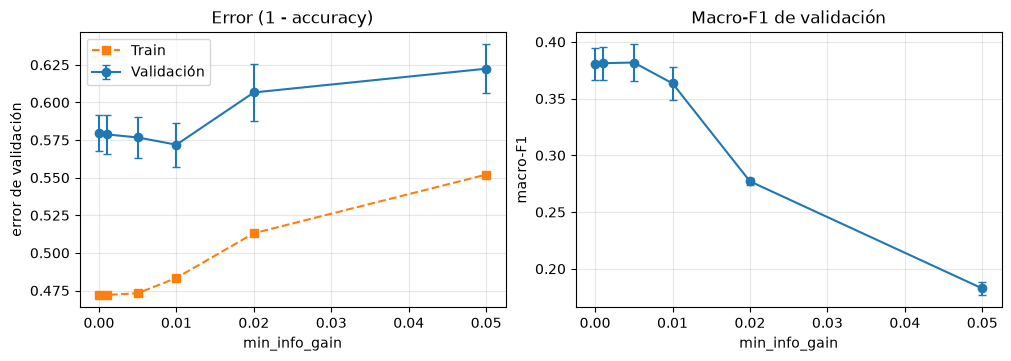

min_info_gain elegido: 0.005
Con ese umbral el árbol tiene profundidad 6 y 589 hojas


In [12]:
grid_gain = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]
filas_id3 = []
for ganancia in grid_gain:
    detalle = evaluate_temporal_cv(
        ID3(min_info_gain=ganancia), train, folds, 'discrete'
    )
    arbol_tmp = ID3(min_info_gain=ganancia).fit(X_train, train['winner'])
    filas_id3.append({
        'min_info_gain': ganancia,
        'error_validacion': detalle.validation_error.mean(),
        'error_validacion_std': detalle.validation_error.std(ddof=0),
        'macro_f1': detalle.macro_f1.mean(),
        'macro_f1_std': detalle.macro_f1.std(ddof=0),
        'error_train': detalle.train_error.mean(),
        'profundidad': arbol_tmp.get_depth(),
        'hojas': arbol_tmp.get_n_leaves(),
    })
cv_id3 = pd.DataFrame(filas_id3)
display(cv_id3.round(6))

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
ejes[0].errorbar(cv_id3['min_info_gain'], cv_id3['error_validacion'],
                 yerr=cv_id3['error_validacion_std'], marker='o', capsize=3, label='Validación')
ejes[0].plot(cv_id3['min_info_gain'], cv_id3['error_train'],
             marker='s', linestyle='--', label='Train')
ejes[0].legend()
ejes[0].set(xlabel='min_info_gain', ylabel='error de validación',
            title='Error (1 - accuracy)')
ejes[1].errorbar(cv_id3['min_info_gain'], cv_id3['macro_f1'],
                 yerr=cv_id3['macro_f1_std'], marker='o', capsize=3)
ejes[1].set(xlabel='min_info_gain', ylabel='macro-F1',
            title='Macro-F1 de validación')
for eje in ejes:
    eje.grid(alpha=0.3)
plt.show()

id3_gain = float(
    cv_id3.sort_values(['macro_f1', 'min_info_gain'],
                       ascending=[False, True]).iloc[0]['min_info_gain']
)
fila_elegida = cv_id3[cv_id3['min_info_gain'] == id3_gain].iloc[0]
print('min_info_gain elegido:', id3_gain)
print(f'Con ese umbral el árbol tiene profundidad {fila_elegida["profundidad"]:.0f} '
      f'y {fila_elegida["hojas"]:.0f} hojas')

Vemos la misma medición de dos formas. El error de validación
(1 - accuracy) es mínimo en `min_info_gain=0.01`, pero el macro-F1 alcanza
su máximo nominal en `0.005`. Elegimos por macro-F1, el criterio declarado
antes de evaluar. Las diferencias entre 0, 0.001 y 0.005 son pequeñas y los
resultados varían entre años; las barras muestran desviación entre folds,
no intervalos de confianza ni una prueba de significación. Sobre las seis tasas,
0.005 reduce el árbol de 644 a 589 hojas. La comparación de atributos posterior
puede cambiar el tamaño del árbol final. Con 0.02 o más se observa una caída
marcada de macro-F1 por una prepoda más fuerte.

## 9. Naive Bayes propio

Naive Bayes combina la frecuencia de cada clase con la de sus atributos,
asumiendo independencia entre atributos dada la clase. Nuestra implementación
(`MEstimateCategoricalNB`) usa suavizado m-estimate:

$$
P(X_j = v \mid Y = c) = \frac{n_{jvc} + m \cdot p_{jv}}{n_c + m}
$$

con un prior uniforme de categorías `p_jv = 1 / K_j` (K_j = 4: tres bines más
el 0 reservado). `m` agrega conteos artificiales y evita probabilidades
cero; cuanto mayor es `m`, más se acerca a un prior uniforme y menos pesa la
frecuencia observada.

`CategoricalNB` de scikit-learn estima `(n + alpha) / (n_c + alpha * K)`, que
coincide con la nuestra tomando `alpha = m / 4`. Por eso barremos `m` sobre la
validación y repetimos la grilla con `CategoricalNB(m/4)`, confirmando la
equivalencia problema a problema.

Elegimos el `m` que maximiza el macro-F1 de validación, con el mismo desempate
que en ID3: ante valores que rinden igual, el menor `m` (no agregamos
suavizado artificial del que los datos no dan evidencia). Las columnas `*_std`
son la desviación estándar entre los tres folds y `error_validacion` es
`1 - accuracy` (sección 7).

,m,alpha,error_validacion,error_validacion_std,macro_f1,macro_f1_sklearn,error_train,error_validacion_sklearn,error_validacion_sklearn_std,error_train_sklearn,macro_f1_std
0,0.1,0.025,0.565633,0.035400,0.363482,0.363482,0.516039,0.565633,0.035400,0.516039,0.032202
1,1.0,0.250,0.565633,0.035400,0.363482,0.363482,0.516039,0.565633,0.035400,0.516039,0.032202
2,10.0,2.500,0.565633,0.035400,0.363482,0.363482,0.516109,0.565633,0.035400,0.516109,0.032202
3,100.0,25.000,0.567146,0.038048,0.358941,0.358941,0.515177,0.567146,0.038048,0.515177,0.033387
4,1000.0,250.000,0.566571,0.029783,0.334176,0.334176,0.511003,0.566571,0.029783,0.511003,0.022262


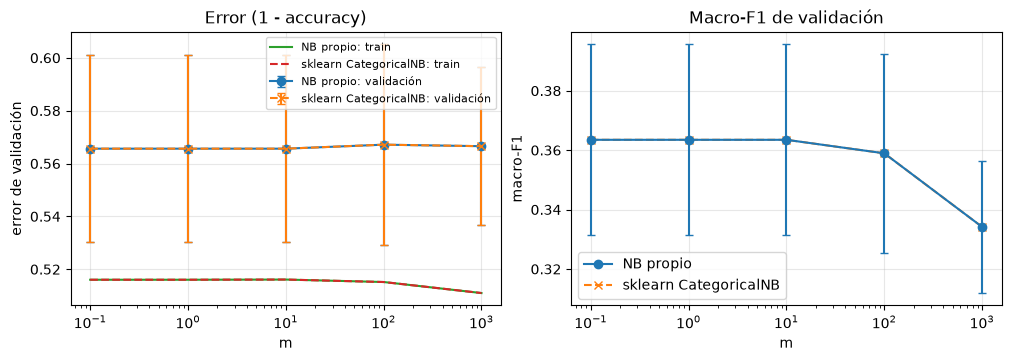

m elegido: 0.1 -> alpha = 0.025


In [13]:
grid_m = [0.1, 1, 10, 100, 1000]
filas_nb = []
for m in grid_m:
    propio = evaluate_temporal_cv(
        MEstimateCategoricalNB(m=m, min_categories=4), train, folds, 'discrete')
    referencia = evaluate_temporal_cv(
        CategoricalNB(alpha=m / 4, min_categories=4, force_alpha=True),
        train, folds, 'discrete')
    filas_nb.append({
        'm': m,
        'alpha': m / 4,
        'error_validacion': propio.validation_error.mean(),
        'error_validacion_std': propio.validation_error.std(ddof=0),
        'macro_f1': propio.macro_f1.mean(),
        'macro_f1_sklearn': referencia.macro_f1.mean(),
        'error_train': propio.train_error.mean(),
        'error_validacion_sklearn': referencia.validation_error.mean(),
        'error_validacion_sklearn_std': referencia.validation_error.std(ddof=0),
        'error_train_sklearn': referencia.train_error.mean(),
        'macro_f1_std': propio.macro_f1.std(ddof=0),
    })
cv_nb = pd.DataFrame(filas_nb)
display(cv_nb.round(6))

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
ejes[0].errorbar(cv_nb['m'], cv_nb['error_validacion'],
                 yerr=cv_nb['error_validacion_std'], marker='o', capsize=3, label='NB propio: validación')
ejes[0].errorbar(cv_nb['m'], cv_nb['error_validacion_sklearn'],
                 yerr=cv_nb['error_validacion_sklearn_std'], marker='x',
                 linestyle='--', capsize=3, label='sklearn CategoricalNB: validación')
ejes[0].plot(cv_nb['m'], cv_nb['error_train'], label='NB propio: train')
ejes[0].plot(cv_nb['m'], cv_nb['error_train_sklearn'], linestyle='--',
             label='sklearn CategoricalNB: train')
ejes[0].legend(fontsize=8)
ejes[0].set(xscale='log', xlabel='m', ylabel='error de validación',
            title='Error (1 - accuracy)')
ejes[1].errorbar(cv_nb['m'], cv_nb['macro_f1'],
                 yerr=cv_nb['macro_f1_std'], marker='o', capsize=3)
ejes[1].set(xscale='log', xlabel='m', ylabel='macro-F1',
            title='Macro-F1 de validación')
ejes[1].plot(cv_nb['m'], cv_nb['macro_f1_sklearn'], marker='x',
             linestyle='--', label='sklearn CategoricalNB')
ejes[1].lines[0].set_label('NB propio')
ejes[1].legend()
for eje in ejes:
    eje.grid(alpha=0.3)
plt.show()

nb_m = float(
    cv_nb.sort_values(['macro_f1', 'm'], ascending=[False, True]).iloc[0]['m']
)
print('m elegido:', nb_m, '-> alpha =', nb_m / 4)

De `m=0.1` a `10` coinciden las métricas de clasificación de los
folds: error 0.5656 y macro-F1 0.3635. El suavizado sí cambia las probabilidades,
aunque no alcanza a cambiar esas métricas. Con `m=100` y `1000` el macro-F1
medio baja a 0.3589 y 0.3342. Las barras describen la variación entre los tres
años; no permiten por sí solas afirmar significación estadística. El desempate
declarado elige el menor valor entre los máximos, `m=0.1`.

Las curvas de NB propio y sklearn CategoricalNB se superponen porque comparten
entradas, dominio K=4 y suavizado equivalente `alpha=m/4`.

## 10. Random Forest: validación de las 12 configuraciones

Se conserva la grilla investigada: profundidades 4, 8 y sin límite; hojas
mínimas 50, 20, 5 y 1. Todas usan las seis tasas continuas, 300 árboles,
balanced_subsample y semilla 42. Seleccionamos por macro-F1 medio anual sin
redondear. En empate exacto se prefiere menor profundidad y luego mayor hoja,
según el orden declarado antes de medir. El error es 1 - accuracy.

,tie_rank,profundidad,min_samples_leaf,error_validacion,error_validacion_std,error_train,macro_f1,macro_f1_std
0,0,4,50,0.594557,0.018663,0.537360,0.394857,0.012353
1,1,4,20,0.594741,0.023170,0.536151,0.394522,0.017162
2,2,4,5,0.594545,0.021320,0.536314,0.394274,0.015023
3,3,4,1,0.594534,0.023994,0.536147,0.394591,0.017663
4,4,8,50,0.586131,0.019975,0.502225,0.402799,0.015801
5,5,8,20,0.583920,0.015302,0.487796,0.405848,0.012488
6,6,8,5,0.588068,0.025400,0.467910,0.401366,0.023134
7,7,8,1,0.590598,0.022325,0.456752,0.398007,0.016472
8,8,sin límite,50,0.579637,0.017172,0.477580,0.408367,0.012287
9,9,sin límite,20,0.565298,0.018507,0.403547,0.422767,0.009563


Random Forest elegido: {'max_depth': None, 'min_samples_leaf': 20}


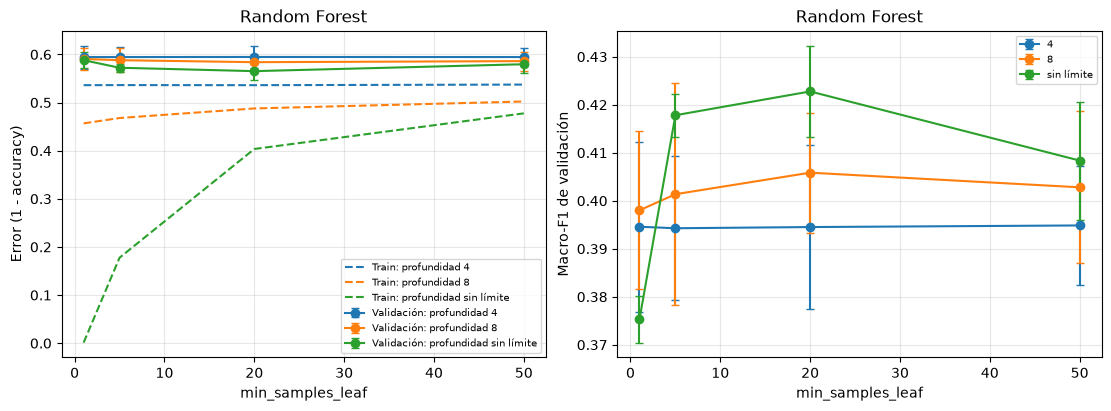

In [14]:
rf_grid = [
    {'max_depth': depth, 'min_samples_leaf': leaf}
    for depth in (4, 8, None) for leaf in (50, 20, 5, 1)
]
filas_rf = []
for tie_rank, params in enumerate(rf_grid):
    detalle = evaluate_temporal_cv(
        RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                               random_state=RANDOM_STATE, n_jobs=2, **params),
        train, folds, 'continuous')
    filas_rf.append({
        'tie_rank': tie_rank,
        'profundidad': 'sin límite' if params['max_depth'] is None else str(params['max_depth']),
        'min_samples_leaf': params['min_samples_leaf'],
        'error_validacion': detalle.validation_error.mean(),
        'error_validacion_std': detalle.validation_error.std(ddof=0),
        'error_train': detalle.train_error.mean(),
        'macro_f1': detalle.macro_f1.mean(),
        'macro_f1_std': detalle.macro_f1.std(ddof=0),
    })
cv_rf = pd.DataFrame(filas_rf)
display(cv_rf.round(6))
rf_rank = int(cv_rf.sort_values(
    ['macro_f1', 'tie_rank'], ascending=[False, True], kind='stable'
).iloc[0]['tie_rank'])
rf_params = rf_grid[rf_rank].copy()
print('Random Forest elegido:', rf_params)

fig, ejes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
for depth, part in cv_rf.groupby('profundidad', sort=False):
    part = part.sort_values('min_samples_leaf')
    line = ejes[0].errorbar(part.min_samples_leaf, part.error_validacion,
                           yerr=part.error_validacion_std, marker='o', capsize=3,
                           label=f'Validación: profundidad {depth}')
    ejes[0].plot(part.min_samples_leaf, part.error_train, linestyle='--',
                 color=line.lines[0].get_color(), label=f'Train: profundidad {depth}')
    ejes[1].errorbar(part.min_samples_leaf, part.macro_f1,
                    yerr=part.macro_f1_std, marker='o', capsize=3, label=depth)
ejes[0].set(ylabel='Error (1 - accuracy)', title='Random Forest')
ejes[1].set(ylabel='Macro-F1 de validación', title='Random Forest')
for eje in ejes:
    eje.set_xlabel('min_samples_leaf')
    eje.grid(alpha=0.3)
    eje.legend(fontsize=7)
plt.show()

## 11. Comparación acotada de atributos

Con los hiperparámetros ya elegidos, comparamos únicamente las seis tasas y
esas mismas tasas más puntos y diferencia de gol recientes de ambos equipos
(diez entradas). ID3, NB propio y sklearn CategoricalNB usan los mismos folds
y la misma discretización: cortes fijos solo para las dos tasas last_5;
terciles aprendidos en el train del fold para el resto.

Seleccionamos cada modelo por macro-F1 medio sin redondear; ante empate se
prefieren seis entradas. No se reajustan hiperparámetros. Reutilizar los folds
para estas decisiones sucesivas puede introducir optimismo. Random Forest
conserva las seis tasas. La selección determina las columnas del ajuste final.

In [15]:
feature_variants = {
    '6 tasas': list(NUMERIC_FEATURES),
    '10 atributos': list(NUMERIC_FEATURES) + [
        'home_points_per_match_5', 'away_points_per_match_5',
        'home_goal_diff_per_match_5', 'away_goal_diff_per_match_5',
    ],
}
feature_models = {
    'ID3': ID3(min_info_gain=id3_gain),
    'NB propio': MEstimateCategoricalNB(m=nb_m, min_categories=4),
    'sklearn CategoricalNB': CategoricalNB(
        alpha=nb_m / 4, min_categories=4, force_alpha=True),
}
filas_atributos = []
for nombre, modelo in feature_models.items():
    for rank, (variante, columnas) in enumerate(feature_variants.items()):
        detalle = evaluate_temporal_cv(
            modelo, train, folds, 'discrete', feature_columns=columnas)
        filas_atributos.append({
            'modelo': nombre, 'variante': variante,
            'n_features': len(columnas), 'tie_rank': rank,
            'macro_f1': detalle.macro_f1.mean(),
            'error_validacion': detalle.validation_error.mean(),
            'error_validacion_std': detalle.validation_error.std(ddof=0),
            'error_train': detalle.train_error.mean(),
        })
comparacion_cols = pd.DataFrame(filas_atributos)
display(comparacion_cols.round(6))


def select_feature_columns(comparison, variants):
    ranked = comparison.sort_values(
        ['macro_f1', 'n_features', 'tie_rank', 'modelo'],
        ascending=[False, True, True, True], kind='stable')
    return {
        row['modelo']: list(variants[row['variante']])
        for _, row in ranked.groupby('modelo', sort=False).head(1).iterrows()
    }


selected_columns = select_feature_columns(comparacion_cols, feature_variants)
id3_columns = selected_columns['ID3']
nb_columns = selected_columns['NB propio']
nb_ref_columns = selected_columns['sklearn CategoricalNB']
display(comparacion_cols.sort_values(
    ['macro_f1', 'n_features', 'tie_rank', 'modelo'],
    ascending=[False, True, True, True], kind='stable'
).groupby('modelo', sort=False).head(1))
print('Hiperparámetros seleccionados:', {
    'ID3 min_info_gain': id3_gain, 'NB m': nb_m,
    'sklearn NB alpha': nb_m / 4, 'Random Forest': rf_params})

,modelo,variante,n_features,tie_rank,macro_f1,error_validacion,error_validacion_std,error_train
0,ID3,6 tasas,6,0,0.381798,0.576739,0.013472,0.473186
1,ID3,10 atributos,10,1,0.400186,0.584623,0.031226,0.379462
2,NB propio,6 tasas,6,0,0.363482,0.565633,0.035400,0.516039
3,NB propio,10 atributos,10,1,0.385798,0.572350,0.037096,0.526476
4,sklearn CategoricalNB,6 tasas,6,0,0.363482,0.565633,0.035400,0.516039
5,sklearn CategoricalNB,10 atributos,10,1,0.385798,0.572350,0.037096,0.526476


,modelo,variante,n_features,tie_rank,macro_f1,error_validacion,error_validacion_std,error_train
1,ID3,10 atributos,10,1,0.400186,0.584623,0.031226,0.379462
3,NB propio,10 atributos,10,1,0.385798,0.572350,0.037096,0.526476
5,sklearn CategoricalNB,10 atributos,10,1,0.385798,0.572350,0.037096,0.526476


Hiperparámetros seleccionados: {'ID3 min_info_gain': 0.005, 'NB m': 0.1, 'sklearn NB alpha': 0.025, 'Random Forest': {'max_depth': None, 'min_samples_leaf': 20}}


## 12. Ajuste final con las configuraciones seleccionadas

Los modelos se ajustan con todo el train hasta 2023. Cada discretizador aprende
sus cuantiles solo de ese train y recibe las columnas elegidas por validación.
El bosque usa exactamente la configuración seleccionada de la grilla.

Para reproducir la evaluación final del informe, usar RUN_FINAL_TEST=True.
RUN_FINAL_TEST=False permite ejecutar solo selección y ajuste. Las métricas
vigentes corresponden a 14.705 partidos de train y 472 de evaluación.

In [16]:
discretizer = new_discretizer(id3_columns).fit(train[id3_columns])
X_train = discretizer.transform(train[id3_columns])
arbol_id3 = ID3(min_info_gain=id3_gain).fit(X_train, train['winner'])

disc_final = new_discretizer(nb_columns).fit(train[nb_columns])
Xnb_train = disc_final.transform(train[nb_columns])
nb_final = MEstimateCategoricalNB(m=nb_m, min_categories=4).fit(
    Xnb_train, train['winner'])
disc_ref = new_discretizer(nb_ref_columns).fit(train[nb_ref_columns])
nb_ref = CategoricalNB(alpha=nb_m / 4, min_categories=4, force_alpha=True).fit(
    disc_ref.transform(train[nb_ref_columns]), train['winner'])

X_train_raw = train[NUMERIC_FEATURES].to_numpy()
y_train = train['winner'].to_numpy()
competidores = {
    'sklearn DT (mismo input)': DecisionTreeClassifier(
        criterion='entropy', random_state=RANDOM_STATE),
    'sklearn DT (tasas crudas)': DecisionTreeClassifier(
        criterion='entropy', random_state=RANDOM_STATE),
    'sklearn RandomForest (tasas crudas)': RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=2, **rf_params),
}
for nombre, modelo in competidores.items():
    modelo.fit(X_train if 'mismo input' in nombre else X_train_raw, y_train)
base_10 = TenYearWinRateClassifier().fit(train[BASELINE_FEATURES], train['winner'])
print('Ajuste completado con train; la evaluación se ejecuta en las siguientes celdas.')

Ajuste completado con train; la evaluación se ejecuta en las siguientes celdas.


## 13. ID3: entrenar y medir sobre el test

Con el umbral y los atributos elegidos, el árbol ya está ajustado con todo
el train. Esta evaluación de 2024-2025 requiere RUN_FINAL_TEST=True. `classification_report` da, para cada clase,
**precision**, **recall**, **F1** y **support**, y dos promedios (macro y
weighted); la **matriz de confusion** los muestra por clase: filas = real,
columnas = predicho. También reportamos la importancia de cada atributo
(ganancia acumulada normalizada) para ver que usa el árbol.

Accuracy: 0.4492
Macro-F1: 0.4238
Profundidad: 8 | hojas: 2465
### ID3 propio
              precision    recall  f1-score   support

           E     0.3036    0.2595    0.2798       131
           L     0.4917    0.6211    0.5488       190
           V     0.5000    0.3974    0.4428       151

    accuracy                         0.4492       472
   macro avg     0.4317    0.4260    0.4238       472
weighted avg     0.4421    0.4492    0.4403       472



,atributo,importancia
0,home_win_rate_last_5,0.126737
8,home_goal_diff_per_match_5,0.124390
2,home_win_rate_season,0.117994
3,away_win_rate_season,0.108342
6,home_points_per_match_5,0.101814
1,away_win_rate_last_5,0.100336
7,away_points_per_match_5,0.097930
5,home_win_rate_h2h_as_home,0.097094
9,away_goal_diff_per_match_5,0.089798
4,home_win_rate_as_home_all,0.035564


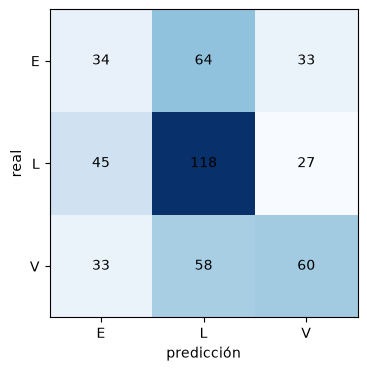

In [17]:
if RUN_FINAL_TEST:
    X_test = discretizer.transform(test[id3_columns])
    y_test = test['winner'].to_numpy()
    y_pred = arbol_id3.predict(X_test)

    print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
    print('Macro-F1:', round(
        f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
    print('Profundidad:', arbol_id3.get_depth(), '| hojas:', arbol_id3.get_n_leaves())
    reporte_por_clases('ID3 propio', y_test, y_pred)

    importancias = pd.DataFrame({
        'atributo': id3_columns,
        'importancia': arbol_id3.feature_importances_,
    }).sort_values('importancia', ascending=False)
    display(importancias)

    matriz = confusion_matrix(y_test, y_pred, labels=CLASSES)
    fig, axis = plt.subplots(figsize=(4.5, 4))
    axis.imshow(matriz, cmap='Blues')
    axis.set(xticks=range(3), xticklabels=CLASSES,
             yticks=range(3), yticklabels=CLASSES,
             xlabel='predicción', ylabel='real')
    for fila in range(3):
            for col in range(3):
                axis.text(col, fila, str(matriz[fila, col]),
                          ha='center', va='center')
    plt.show()
else:
    print('Evaluación final pendiente: RUN_FINAL_TEST=False.')

El ID3 final usa diez atributos y `min_info_gain=0.005`: accuracy
0.4492 y macro-F1 0.4238. Predice L en 240 de los 472 partidos (50,8%), aunque
hay 190 victorias locales reales (40,3%). Reconoce 118 de esas victorias (62,1%),
34 de 131 empates (26,0%) y 60 de 151 victorias visitantes (39,7%). La clase E
es la de menor F1; accuracy y macro-F1 resumen de manera distinta ese desbalance.

## 14. Ejemplos: donde acierta y donde falla

Vemos partidos reales de test con la predicción. La columna `acierta` indica
si el árbol acerto. Los empates son la clase que más se pierde.

In [18]:
if RUN_FINAL_TEST:
    predicciones = test[['date', 'home', 'away', 'winner']].copy()
    predicciones['prediccion_id3'] = y_pred
    predicciones['acierta'] = predicciones['prediccion_id3'] == predicciones['winner']
    display(predicciones.sample(8, random_state=RANDOM_STATE))
    print('Aciertos totales:', int(predicciones['acierta'].sum()), '/', len(predicciones))

    empates_reales = predicciones[predicciones['winner'] == 'E']
    print('Sobre los', len(empates_reales), 'empates reales del test, '
          f'ID3 predijo empate en '
          f'{(empates_reales["prediccion_id3"] == "E").sum()} '
          f'({(empates_reales["prediccion_id3"] == "E").mean():.1%}).')
    display(empates_reales.head(3))
else:
    print('Evaluación final pendiente: RUN_FINAL_TEST=False.')

,date,home,away,winner,prediccion_id3,acierta
55,2024-04-13,CA Cerro,CA Fenix,E,E,True
73,2024-04-27,Rampla Juniors Futbol Club,Deportivo Maldonado,E,L,False
33,2024-03-23,Nacional,CA Progreso,E,L,False
278,2024-11-18,CA Progreso,CA Fenix,E,V,False
244,2024-10-20,Cerro Largo FC,Danubio,E,L,False
380,2025-04-13,Boston River,Cerro Largo FC,L,V,False
211,2024-09-29,Defensor Sporting,Deportivo Maldonado,L,L,True
9,2024-02-24,Montevideo Wanderers,Racing Club,V,V,True


Aciertos totales: 212 / 472
Sobre los 131 empates reales del test, ID3 predijo empate en 34 (26.0%).


,date,home,away,winner,prediccion_id3,acierta
3,2024-02-18,CA Cerro,Montevideo Wanderers,E,L,False
5,2024-02-18,Racing Club,Liverpool,E,L,False
8,2024-02-24,Boston River,Danubio,E,L,False


### 14.1. Predicción de un partido nuevo

Para demostrar que un modelo entrenado sirve para clasificar una instancia
nueva, `predict_new_match` (definida en la seccion 1.2) aplica a un partido
hipotetico exactamente el mismo calculo de atributos del resto del notebook:
solo partidos anteriores, los mismos calculos y la misma imputación neutra si
no hay historial. No se reimplementan tasas ni se le pasa ningun resultado.

Tomamos tres partidos futuros (no estan en el dataset) y los clasificamos con
dos modelos ya entrenados: el ID3 propio (discretizado) y el clasificador base
(tasas crudas). No buscamos optimizar nada, solo mostrar el uso.

In [19]:
if RUN_FINAL_TEST:
    base_demo = TenYearWinRateClassifier().fit(
        train[BASELINE_FEATURES], train['winner'])

    partidos_nuevos = [
        ('Nacional', 'CA Penarol', '2025-11-16'),
        ('Boston River', 'Torque FC', '2025-11-16'),
        ('CA Juventud', 'Plaza Colonia', '2025-11-16'),
    ]

    filas_demo = []
    for home, away, fecha in partidos_nuevos:
        id3_demo = predict_new_match(
            home, away, fecha, matches, arbol_id3,
            feature_columns=id3_columns, discretizer=discretizer)
        base_demo_pred = predict_new_match(
            home, away, fecha, matches, base_demo,
            feature_columns=BASELINE_FEATURES, discretizer=None)
        filas_demo.append({
            'fecha': fecha,
            'partido': f'{home} vs {away}',
            'forma local': round(id3_demo['features']['home_win_rate_last_5'], 2),
            'forma visitante': round(id3_demo['features']['away_win_rate_last_5'], 2),
            'h2h local': round(id3_demo['features']['home_win_rate_h2h_as_home'], 2),
            'ID3': id3_demo['prediccion'],
            'Base 10 años': base_demo_pred['prediccion'],
        })
    display(pd.DataFrame(filas_demo))
else:
    print('Evaluación final pendiente: RUN_FINAL_TEST=False.')

,fecha,partido,forma local,forma visitante,h2h local,ID3,Base 10 años
0,2025-11-16,Nacional vs CA Penarol,1.0,0.8,0.41,L,L
1,2025-11-16,Boston River vs Torque FC,0.2,0.2,0.43,L,L
2,2025-11-16,CA Juventud vs Plaza Colonia,0.8,0.2,0.17,V,V


## 15. Comparadores

Comparamos el ID3 propio con:

- `sklearn DecisionTree` con el mismo input discretizado: sirve para comparar
  nuestra implementación con la de la biblioteca, con el mismo input para las
  dos.
- `sklearn DecisionTree` con las tasas crudas: puede cortar en cualquier
  umbral; es una comparación exploratoria, con seis entradas frente a las
  diez del árbol sobre códigos. No aísla el efecto de discretizar.
- `sklearn RandomForest` (300 árboles, `class_weight='balanced_subsample'`):
  el bosque da más peso a las clases chicas en cada árbol para no ignorar el
  empate. Se evalúa con la configuración elegida por validación temporal.
- El clasificador base: gana el equipo con mayor proporción de victorias en
  los últimos diez años (una regla fija, sin aprendizaje).

Todos se entrenan solo con train y se evalúan sobre el mismo test de
2024-2025; la tabla compara accuracy y macro-F1 (sección 7).

El bosque usa la profundidad y hoja mínima elegidas en la sección 10.
La evaluación está activada en la entrega.

In [20]:
if RUN_FINAL_TEST:
    X_test_raw = test[NUMERIC_FEATURES].to_numpy()

    filas_comp = []
    predicciones_comp = {}
    for nombre, modelo in competidores.items():
        usa_codigos = 'mismo input' in nombre
        X_entrena = X_train if usa_codigos else X_train_raw
        X_prueba = X_test if usa_codigos else X_test_raw
        predicha = modelo.predict(X_prueba)
        predicciones_comp[nombre] = predicha
        filas_comp.append({
            'modelo': nombre,
            'accuracy': round(accuracy_score(y_test, predicha), 4),
            'macro_f1': round(
                f1_score(y_test, predicha, average='macro', zero_division=0), 4),
        })

    pred_base = base_10.predict(test[BASELINE_FEATURES])
    filas_comp.append({
        'modelo': 'Base 10 años (clasificador base)',
        'accuracy': round(accuracy_score(y_test, pred_base), 4),
        'macro_f1': round(
            f1_score(y_test, pred_base, average='macro', zero_division=0), 4),
    })
    filas_comp.append({
        'modelo': 'ID3 propio',
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'macro_f1': round(
            f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
    })
    display(pd.DataFrame(filas_comp))
else:
    print('Evaluación final pendiente: RUN_FINAL_TEST=False.')

,modelo,accuracy,macro_f1
0,sklearn DT (mismo input),0.4364,0.4124
1,sklearn DT (tasas crudas),0.3602,0.3531
2,sklearn RandomForest (tasas crudas),0.4258,0.4219
3,Base 10 años (clasificador base),0.4619,0.3564
4,ID3 propio,0.4492,0.4238


## 16. Naive Bayes: evaluación final

Ambos NB ya se ajustaron usando las columnas elegidas por validación y el mismo
preprocesado de la búsqueda. Este bloque solo evalúa si RUN_FINAL_TEST=True.

Same predictions (propio vs CategoricalNB): True
Accuracy NB: 0.4788
Macro-F1 NB: 0.4454
### NB propio (10 atributos)
              precision    recall  f1-score   support

           E     0.3537    0.2214    0.2723       131
           L     0.5475    0.6368    0.5888       190
           V     0.4497    0.5033    0.4750       151

    accuracy                         0.4788       472
   macro avg     0.4503    0.4538    0.4454       472
weighted avg     0.4624    0.4788    0.4646       472



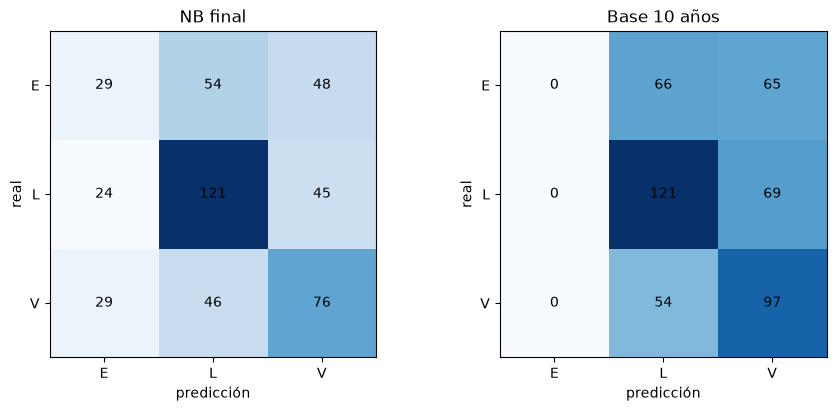

In [21]:
if RUN_FINAL_TEST:
    Xnb_test = disc_final.transform(test[nb_columns])
    Xnb_ref_test = disc_ref.transform(test[nb_ref_columns])
    pred_nb = nb_final.predict(Xnb_test)
    pred_ref = nb_ref.predict(Xnb_ref_test)
    print('Same predictions (propio vs CategoricalNB):',
          bool((pred_nb == pred_ref).all()))
    print('Accuracy NB:', round(accuracy_score(y_test, pred_nb), 4))
    print('Macro-F1 NB:', round(
        f1_score(y_test, pred_nb, average='macro', zero_division=0), 4))
    reporte_por_clases(f'NB propio ({len(nb_columns)} atributos)', y_test, pred_nb)

    fig, ejes = plt.subplots(1, 2, figsize=(9, 4), layout='constrained')
    for eje, (nombre, pred) in zip(ejes, [('NB final', pred_nb),
                                          ('Base 10 años', pred_base)]):
        matriz = confusion_matrix(y_test, pred, labels=CLASSES)
        eje.imshow(matriz, cmap='Blues')
        eje.set(xticks=range(3), xticklabels=CLASSES,
                yticks=range(3), yticklabels=CLASSES,
                xlabel='predicción', ylabel='real', title=nombre)
        for fila in range(3):
            for col in range(3):
                eje.text(col, fila, str(matriz[fila, col]),
                         ha='center', va='center')
    plt.show()
else:
    print('Evaluación final pendiente: RUN_FINAL_TEST=False.')

Los NB finales coinciden en las 472 etiquetas: accuracy 0.4788 y macro-F1
0.4454. El baseline obtiene 0.4619 y 0.3564, respectivamente.

## 17. Efectividad del algoritmo

Juntamos todo en una tabla sobre el mismo test y lo comparamos con la regla
trivial de predecir siempre L (la clase mayoritaria). Además vemos cuántos
empates captura cada modelo.

In [22]:
if RUN_FINAL_TEST:
    siempre_l = np.full(len(y_test), 'L')
    filas_resumen = filas_comp + [
        {'modelo': f'NB propio ({len(nb_columns)} atributos)',
         'accuracy': round(accuracy_score(y_test, pred_nb), 4),
         'macro_f1': round(
             f1_score(y_test, pred_nb, average='macro', zero_division=0), 4)},
        {'modelo': 'Siempre L',
         'accuracy': round(accuracy_score(y_test, siempre_l), 4),
         'macro_f1': round(
             f1_score(y_test, siempre_l, average='macro', zero_division=0), 4)},
    ]
    resumen = pd.DataFrame(filas_resumen)
    display(resumen.sort_values('accuracy', ascending=False).reset_index(drop=True))

    print('Empates reales en test:', int((y_test == 'E').sum()),
          'de', len(y_test))
    for nombre, pred in [('ID3', y_pred), ('NB final', pred_nb),
                         ('Base 10 años', pred_base)]:
        print(f'{nombre:<15} predijo E en '
              f'{int((pred == "E").sum())} partidos '
              f'(acierto {(pred[y_test == "E"] == "E").mean():.1%} de los reales)')
else:
    print('Evaluación final pendiente: RUN_FINAL_TEST=False.')

,modelo,accuracy,macro_f1
0,NB propio (10 atributos),0.4788,0.4454
1,Base 10 años (clasificador base),0.4619,0.3564
2,ID3 propio,0.4492,0.4238
3,sklearn DT (mismo input),0.4364,0.4124
4,sklearn RandomForest (tasas crudas),0.4258,0.4219
5,Siempre L,0.4025,0.1913
6,sklearn DT (tasas crudas),0.3602,0.3531


Empates reales en test: 131 de 472
ID3             predijo E en 112 partidos (acierto 26.0% de los reales)
NB final        predijo E en 82 partidos (acierto 22.1% de los reales)
Base 10 años    predijo E en 0 partidos (acierto 0.0% de los reales)


### 17.1. Métricas por clase de los cinco modelos

La misma función `reporte_por_clases` mide a los cinco modelos sobre el mismo
test. Ya la usamos arriba para ID3 y NB propio; la repetimos acá con todos los
comparadores para ver de un vistazo como rinde cada clase (definiciones en la
sección 7).

In [23]:
if RUN_FINAL_TEST:
    reporte_por_clases('Base 10 años', y_test, pred_base)
    reporte_por_clases('sklearn DT (mismo input)', y_test,
                       predicciones_comp['sklearn DT (mismo input)'])
    reporte_por_clases('sklearn RandomForest (tasas crudas)', y_test,
                       predicciones_comp['sklearn RandomForest (tasas crudas)'])
    reporte_por_clases('sklearn CategoricalNB', y_test, pred_ref)

    # Tablas y diagnóstico ya retenidos en el informe; sin nuevos ajustes.
    predicciones_informe = {
        'ID3': y_pred, 'NB propio': pred_nb, 'CategoricalNB': pred_ref,
        'Random Forest': predicciones_comp['sklearn RandomForest (tasas crudas)'],
        'Base 10 años': pred_base,
    }
    metricas_informe = pd.DataFrame([
        {'model': nombre, 'n_test': len(y_test),
         'correct': int((pred == y_test).sum()),
         'accuracy': accuracy_score(y_test, pred),
         'macro_f1': f1_score(y_test, pred, labels=CLASSES,
                              average='macro', zero_division=0)}
        for nombre, pred in predicciones_informe.items()
    ])
    display(metricas_informe)
    for nombre, pred in predicciones_informe.items():
        print(nombre, '(filas reales, columnas predichas: E/L/V)')
        display(pd.DataFrame(confusion_matrix(y_test, pred, labels=CLASSES),
                             index=CLASSES, columns=CLASSES))
    print('Máxima diferencia absoluta de probabilidades NB:',
          np.max(np.abs(nb_final.predict_proba(Xnb_test)
                        - nb_ref.predict_proba(Xnb_ref_test))))

    ejemplos_informe = test[['date', 'home', 'away', 'winner']].copy()
    ejemplos_informe['prediction_nb_propio'] = pred_nb
    ejemplos_informe = ejemplos_informe.merge(
        matches[['date', 'home', 'away', 'gh', 'ga']],
        on=['date', 'home', 'away'], validate='one_to_one')
    ejemplos_informe['score'] = (
        ejemplos_informe['gh'].astype(str) + '-' + ejemplos_informe['ga'].astype(str))
    ejemplos_informe = (
        ejemplos_informe.sort_values(['date', 'home', 'away'])
        .groupby(['winner', 'prediction_nb_propio'], sort=True, as_index=False)
        .head(1).sort_values(['winner', 'prediction_nb_propio']).reset_index(drop=True))
    display(ejemplos_informe)

    senal = np.select(
        [test['home_points_per_match_5'] > test['away_points_per_match_5'],
         test['home_points_per_match_5'] < test['away_points_per_match_5']],
        ['Local > visitante', 'Local < visitante'], default='Local = visitante')
    filas_escenarios = []
    for grupo in ('Local > visitante', 'Local = visitante', 'Local < visitante'):
        mascara = senal == grupo
        for nombre, pred in predicciones_informe.items():
            filas_escenarios.append({
                'subgroup': grupo, 'model': nombre, 'n_test': int(mascara.sum()),
                'actual_E_L_V': '/'.join(str(int((y_test[mascara] == c).sum()))
                                         for c in CLASSES),
                'correct': int((pred[mascara] == y_test[mascara]).sum()),
                'accuracy': accuracy_score(y_test[mascara], pred[mascara]),
                'macro_f1': f1_score(y_test[mascara], pred[mascara], labels=CLASSES,
                                     average='macro', zero_division=0),
            })
    escenarios_informe = pd.DataFrame(filas_escenarios)
    display(escenarios_informe)
else:
    print('Evaluación omitida: RUN_FINAL_TEST=False; usar True para reproducir el informe.')


### Base 10 años
              precision    recall  f1-score   support

           E     0.0000    0.0000    0.0000       131
           L     0.5021    0.6368    0.5615       190
           V     0.4199    0.6424    0.5079       151

    accuracy                         0.4619       472
   macro avg     0.3073    0.4264    0.3564       472
weighted avg     0.3364    0.4619    0.3885       472

### sklearn DT (mismo input)
              precision    recall  f1-score   support

           E     0.2960    0.2824    0.2891       131
           L     0.5022    0.6105    0.5511       190
           V     0.4569    0.3510    0.3970       151

    accuracy                         0.4364       472
   macro avg     0.4184    0.4147    0.4124       472
weighted avg     0.4305    0.4364    0.4291       472

### sklearn RandomForest (tasas crudas)
              precision    recall  f1-score   support

           E     0.2975    0.3588    0.3253       131
           L     0.5725    0.4158    0.4817

,model,n_test,correct,accuracy,macro_f1
0,ID3,472,212,0.449153,0.423826
1,NB propio,472,226,0.478814,0.445369
2,CategoricalNB,472,226,0.478814,0.445369
3,Random Forest,472,201,0.425847,0.421894
4,Base 10 años,472,218,0.461864,0.356446


ID3 (filas reales, columnas predichas: E/L/V)


,E,L,V
E,34,64,33
L,45,118,27
V,33,58,60


NB propio (filas reales, columnas predichas: E/L/V)


...

Base 10 años (filas reales, columnas predichas: E/L/V)


,E,L,V
E,0,66,65
L,0,121,69
V,0,54,97


Máxima diferencia absoluta de probabilidades NB: 1.9984014443252818e-15


,date,home,away,winner,prediction_nb_propio,gh,ga,score
0,2024-03-11,Montevideo Wanderers,Deportivo Maldonado,E,E,0,0,0-0
1,2024-02-25,Cerro Largo FC,CA Fenix,E,L,0,0,0-0
2,2024-02-18,CA Cerro,Montevideo Wanderers,E,V,1,1,1-1
3,2024-04-07,CA Cerro,Rampla Juniors Futbol Club,L,E,3,0,3-0
4,2024-02-17,Nacional,River Plate,L,L,2,1,2-1
5,2024-03-02,River Plate,Danubio,L,V,1,0,1-0
6,2024-02-24,Montevideo Wanderers,Racing Club,V,E,0,1,0-1
7,2024-02-18,Deportivo Maldonado,Boston River,V,L,1,2,1-2
8,2024-02-17,CA Fenix,Danubio,V,V,1,2,1-2


,subgroup,model,n_test,actual_E_L_V,correct,accuracy,macro_f1
0,Local > visitante,ID3,216,62/106/48,96,0.444444,0.352770
1,Local > visitante,NB propio,216,62/106/48,116,0.537037,0.378779
2,Local > visitante,CategoricalNB,216,62/106/48,116,0.537037,0.378779
3,Local > visitante,Random Forest,216,62/106/48,98,0.453704,0.411678
4,Local > visitante,Base 10 años,216,62/106/48,99,0.458333,0.331746
5,Local = visitante,ID3,39,9/15/15,18,0.461538,0.415242
6,Local = visitante,NB propio,39,9/15/15,15,0.384615,0.373720
7,Local = visitante,CategoricalNB,39,9/15/15,15,0.384615,0.373720
8,Local = visitante,Random Forest,39,9/15/15,14,0.358974,0.355556
9,Local = visitante,Base 10 años,39,9/15/15,21,0.538462,0.403716


### Interpretación de los resultados del informe

NB propio y CategoricalNB coinciden en las 472 predicciones. NB acierta 226
partidos frente a 218 del baseline: son ocho aciertos adicionales, 1,69 puntos
porcentuales de accuracy y 0,0889 de macro-F1. ID3 y Random Forest superan al
baseline en macro-F1, aunque tienen menor accuracy. El criterio de selección
fue macro-F1 de validación, que da el mismo peso a E, L y V.

La dificultad principal es E. NB reconoce 29 de 131 empates (22,1%); ID3, 34
(26,0%); y Random Forest, 47 (35,9%). El bosque también produce 111 falsos
empates: reconocer más E no garantiza mejorar las métricas globales. Frente
al baseline, NB mantiene 121 victorias locales acertadas y baja de 97 a 76
victorias visitantes, a cambio de reconocer 29 empates. Su ventaja no es
uniforme entre clases.

Los ejemplos toman el primer partido de cada combinación real/predicha de NB;
son ilustrativos. Al agrupar por diferencia de puntos recientes, NB mejora
sobre el baseline cuando el local tiene mayor promedio (116 frente a 99 aciertos
en 216 partidos), pero no en los otros dos grupos. Su composición de clases es
distinta, por lo que el diagnóstico no demuestra un efecto causal del atributo.

Los modelos y cortes permanecen fijos durante test; los históricos incorporan
solo fechas anteriores. El bloque ya había sido inspeccionado, se reutilizan
folds para varias decisiones y 2025 termina en junio: los resultados describen
esta ejecución, sin constituir evidencia confirmatoria sobre datos nuevos.
No se realizaron pruebas de significación. Los árboles adicionales de sklearn
son comparadores exploratorios: usan distintas cantidades de atributos y no
permiten aislar el efecto de discretizar. ID3 puede representar interacciones
mediante ramas sucesivas; NB supone independencia condicional dada la clase.
